<a href="https://colab.research.google.com/github/amelyssaeu-ab/bio-dkm/blob/main/semana06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Regressão Linear Simples e Correlação de Pearson em Dados Biológicos

######**Drielly Mathias Albertti - nº 16831084**
######**Kawana Ganeo de Carvalho - nº 14669691**
######**Melyssa Ponce Lopes - nº 16831017**


## 1. Identificação da Base de Dados e Origem
* **Fonte completa:** Gorman KB, Williams TD, Fraser WR (2014). *Ecological Sexual Dimorphism and Environmental Variability within a Community of Antarctic Penguins (Genus Pygoscelis)*. PLOS ONE 9(3): e90081.
* **Link de acesso:** `https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv`
* **Instituição/Responsável:** Dr. Kristen Gorman / Palmer Station Long Term Ecological Research (LTER)
* **Data de acesso:** 25 de agosto de 2026

## 2. Apresentação do Conjunto de Dados
O conjunto de dados contém medições morfológicas de pinguins coletadas no Arquipélago Palmer, na Antártida. Para esta análise, é investigada a relação entre duas variáveis quantitativas contínuas:
* **Variável Independente ($X$):** Comprimento da nadadeira do pinguim em milímetros (mm).
* **Variável Dependente ($Y$):** Massa corporal total do pinguim em gramas (g).

Intercepto (beta_0): -5780.83
Coeficiente Angular (beta_1): 49.69
Coeficiente de Correlação de Pearson (r): 0.8712


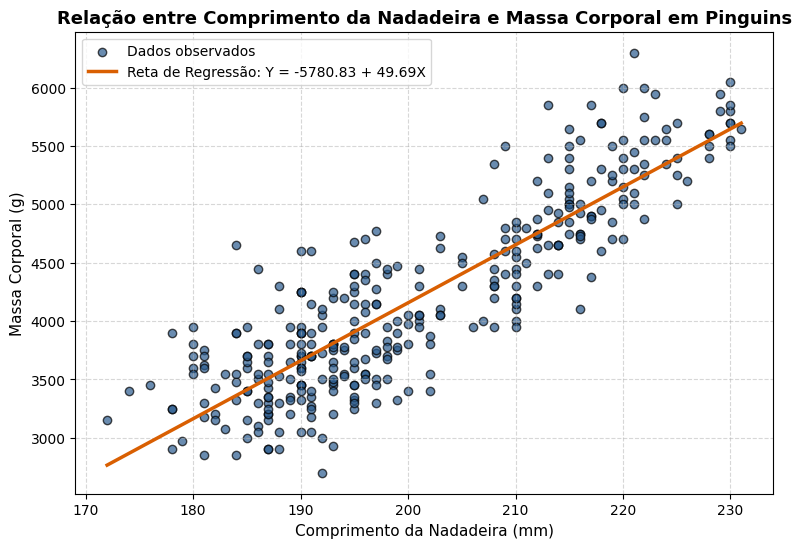

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Carregamento e limpeza dos dados
df = pd.read_csv('dataset_seaborn.csv')
dados = df[['flipper_length_mm', 'body_mass_g']].dropna()

x = dados['flipper_length_mm']
y = dados['body_mass_g']

# 2. Estimação dos coeficientes da regressão linear simples (Y = beta_0 + beta_1 * X)
slope, intercept = np.polyfit(x, y, 1)

# 3. Cálculo do Coeficiente de Correlação de Pearson (r)
r = np.corrcoef(x, y)[0, 1]

print(f"Intercepto (beta_0): {intercept:.2f}")
print(f"Coeficiente Angular (beta_1): {slope:.2f}")
print(f"Coeficiente de Correlação de Pearson (r): {r:.4f}")

# 4. Gráfico de dispersão com a reta de regressão
plt.figure(figsize=(9, 6))
plt.scatter(x, y, color='#2b5c8f', alpha=0.7, edgecolors='k', label='Dados observados')

# Reta de regressão estimada
x_linha = np.linspace(x.min(), x.max(), 100)
y_linha = intercept + slope * x_linha
plt.plot(x_linha, y_linha, color='#d95f02', linewidth=2.5, label=f'Reta de Regressão: Y = {intercept:.2f} + {slope:.2f}X')

plt.title('Relação entre Comprimento da Nadadeira e Massa Corporal em Pinguins', fontsize=13, fontweight='bold')
plt.xlabel('Comprimento da Nadadeira (mm)', fontsize=11)
plt.ylabel('Massa Corporal (g)', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 3. Fundamentação Teórica e Fórmulas

### Regressão Linear Simples
A Regressão Linear Simples é um método estatístico utilizado para modelar a relação funcional entre uma variável que "pergunta" (independente, X) e uma variável que "responde" a variável x (dependente, Y). O objetivo é encontrar a reta que melhor se ajusta aos pontos observados, minimizando a soma dos quadrados dos resíduos.

A fórmula do modelo é dada por:

$$Y = \beta_0 + \beta_1 X + \epsilon$$

Onde as estimativas dos coeficientes pelos Mínimos Quadrados Ordinários (MQO) são:

$$\beta_1 = \frac{\sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})}{\sum_{i=1}^{n} (X_i - \bar{X})^2}$$

$$\beta_0 = \bar{Y} - \beta_1 \bar{X}$$

### Correlação Linear de Pearson
O **Coeficiente de Correlação de Pearson (r)** mede a força e a direção da associação linear entre duas variáveis contínuas, variando no intervalo de $-1$ a $+1$.

Sua fórmula matemática é expressa por:

$$r = \frac{\sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum_{i=1}^{n} (X_i - \bar{X})^2} \cdot \sqrt{\sum_{i=1}^{n} (Y_i - \bar{Y})^2}}$$

## 4. Interpretação e Conclusão

### Interpretação dos Coeficientes da Regressão
* **Coeficiente Angular ($\beta_1$ = 49,69):** Indica que, no contexto estudado, a cada aumento de 1 mm no comprimento da nadadeira, estima-se um ganho médio aproximado de 49,69 g na massa corporal do pinguim.
* **Intercepto ($\beta_0$ = -5780,83):** Representa um valor teórico da massa corporal quando o comprimento da nadadeira é zero. Trata-se de uma extrapolação puramente matemática, sem significado real, pois não é possivel existir pinguins com nadadeiras de 0 mm.

### Análise da Correlação de Pearson
* O coeficiente obtido foi r $\approx$ 0,8712, indicando uma correlação linear positiva entre o tamanho da nadadeira e a massa corporal.
* **Direção:** Como r > 0, quanto maior o comprimento da nadadeira do indivíduo, maior tende a ser a sua massa corporal.
* **Sobre ausência de correlação linear:** Um valor de r $\approx$ 0 demonstraria a ausência de uma associação linear, mas não descartaria relações não lineares (como curvas quadráticas ou exponenciais). Neste caso, o ajuste linear mostrou-se adequado.

### Conclusão
A regressão linear simples e a correlação de Pearson são ferramentas essenciais para analises quantitativas, pois permitem ilustrar a dependência entre estruturas morfológicas (por exemplo) e predizer variáveis de difícil mensuração em campo (como a massa corporal) a partir de medições mais simples (como o comprimento de uma parte corporal específica).